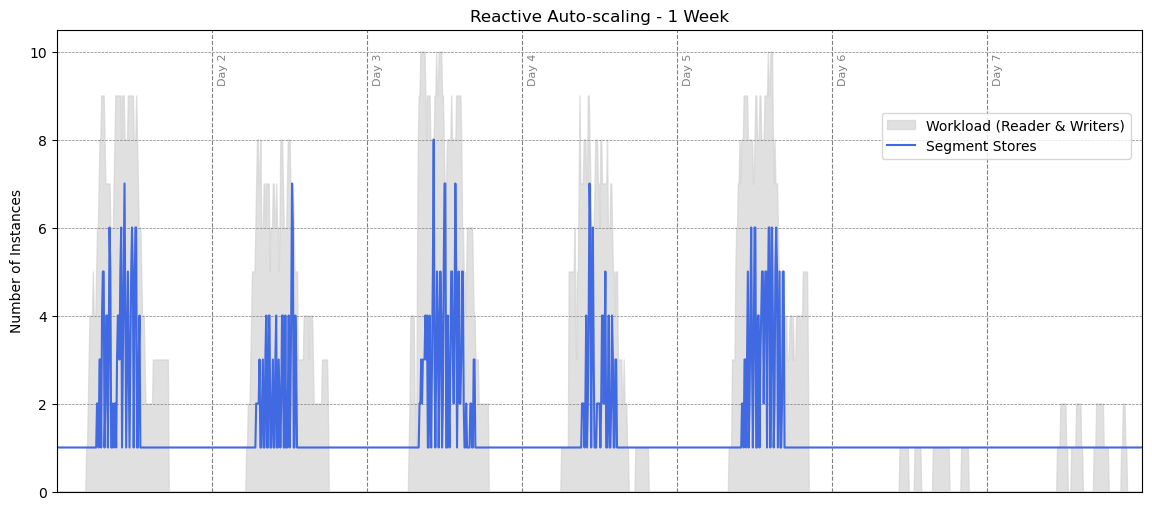

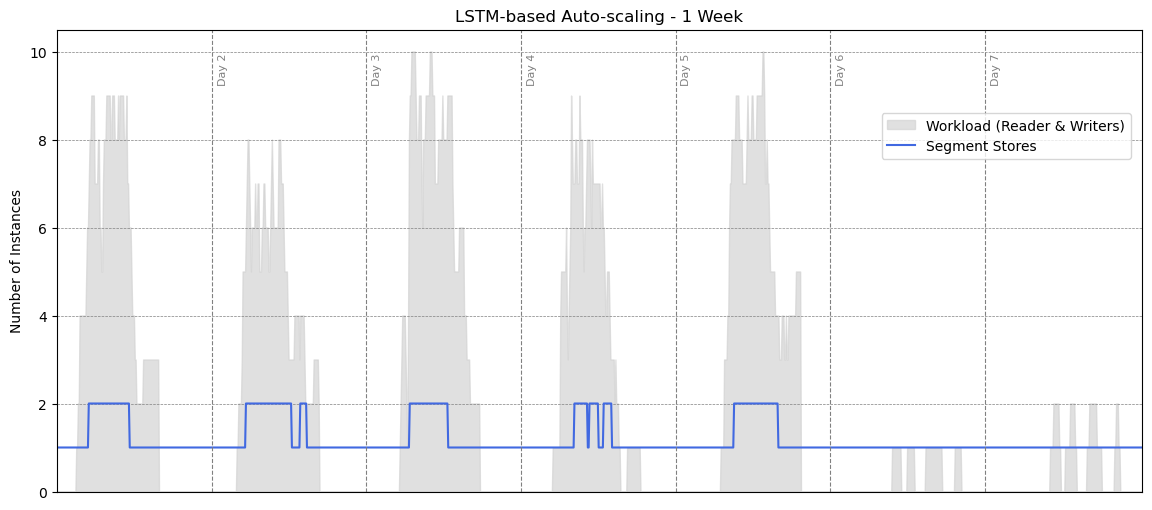

In [ ]:

"""
Plots cluster pod statistics, provided the CSVs for each run

Typical CSV:
    time,workload,stores
    11/3/2025 21:05,0,1
    11/3/2025 21:05,0,1
    ...
"""
import pandas as pd
import matplotlib.pyplot as plt

def plot(file: str, title: str):
    df = pd.read_csv(file)

    plt.figure(figsize=(14, 6))
    plt.fill_between(range(len(df)), df['workload'], color='#D3D3D3', alpha=0.7, label='Workload (Reader & Writers)')
    plt.plot(range(len(df)), df['stores'], label='Segment Stores', color='royalblue', linewidth=1.5)

    # Add six vertical lines for days
    total_points = len(df)
    day_interval = total_points // 7  
    for i in range(1, 7):  
        x_pos = i * day_interval
        plt.axvline(x=x_pos, color='gray', linestyle='--', linewidth=0.8)
        plt.text(x_pos +7 , plt.ylim()[1]*0.95, f'Day {i+1}', rotation=90,
                 verticalalignment='top', fontsize=8, color='gray')

    plt.ylabel('Number of Instances')
    plt.title(title)
    plt.legend(loc=(0.76, 0.72))
    plt.grid(color='gray', linestyle='--', linewidth=0.5)
    plt.xticks([])

    plt.xlim(0, total_points)
    plt.ylim(0,)

    plt.show()


if __name__ == "__main__":
    plot('reactive_1_week.csv', 'Reactive Auto-scaling - 1 Week')
    plot('LSTM_1_week.csv', 'LSTM-based Auto-scaling - 1 Week')
